# Data Visualisation with Housing Data

A practical guide to selecting clear charts for different analytical questions.


## my goal

Use the local Day 3 housing dataset to explore distributions, comparisons, relationships and correlations.


## 1. imports


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path("day_3/Pracs")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load and check the data


In [2]:
housing = pd.read_csv(DATA_DIR / "data_processed.csv").drop(columns=["Unnamed: 0"])
print(f"Rows: {housing.shape[0]:,} | Columns: {housing.shape[1]}")
print(f"Missing values: {housing.isna().sum().sum()}")
housing.head()

Rows: 21,613 | Columns: 22
Missing values: 0


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,0.098361,0.121212,0.18750,0.120755,0.003888,0.2,0.0,0.0,0.50,0.583333,...,0.165217,0.0,0.580808,0.697603,0.107973,0.223886,0.006432,0.0,0.454545,0.500000
1,0.087213,0.151515,0.43750,0.183396,0.006623,0.4,0.0,0.0,0.50,0.666667,...,0.765217,0.0,0.257576,0.789287,0.332226,0.433832,0.012244,0.0,0.545455,0.700000
2,0.027410,0.090909,0.21875,0.093585,0.005500,0.0,0.0,0.0,0.50,0.500000,...,0.765217,0.0,0.207071,0.327328,0.367940,0.220444,0.010372,1.0,0.181818,0.766667
3,0.049836,0.060606,0.12500,0.086038,0.002714,0.2,0.0,0.0,0.25,0.500000,...,0.217391,0.0,0.575758,0.831269,0.182724,0.180864,0.003560,1.0,0.000000,0.866667
4,0.029115,0.090909,0.31250,0.105660,0.002707,0.4,0.0,0.0,0.50,0.500000,...,0.886957,0.0,0.186869,0.322020,0.418605,0.246257,0.004689,0.0,0.818182,0.433333


The dataset is already cleaned and normalised. Chart labels therefore use **normalised values** rather than original dollars or square feet.


## 3. Distribution: histogram

**Question:** How are house prices distributed?


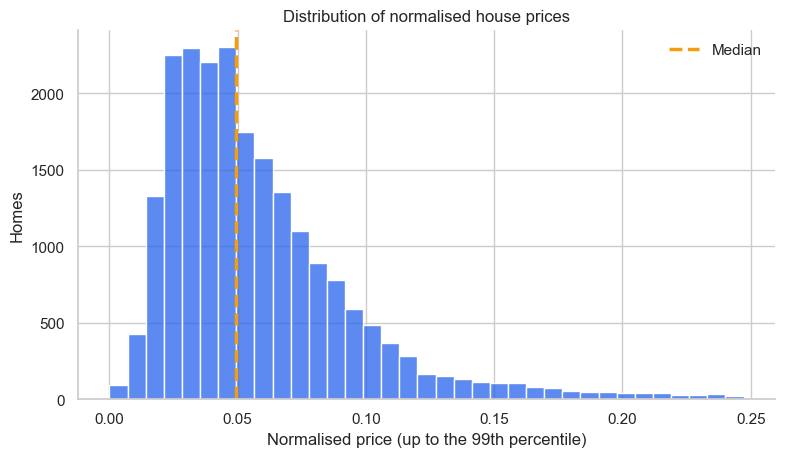

In [3]:
price_limit = housing["price"].quantile(0.99)
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(housing.loc[housing["price"] <= price_limit, "price"], bins=35,
             color="#2563EB", edgecolor="white", ax=ax)
ax.axvline(housing["price"].median(), color="#F59E0B", linestyle="--", linewidth=2.5, label="Median")
ax.set(title="Distribution of normalised house prices", xlabel="Normalised price (up to the 99th percentile)", ylabel="Homes")
ax.legend(frameon=False)
sns.despine()
plt.show()

A histogram is suitable because price is numeric and we want to see its shape. The 99th-percentile view keeps the main distribution readable while clearly stating the limit.


## 4. Relationship: scatter plot

**Question:** Is living area related to price?


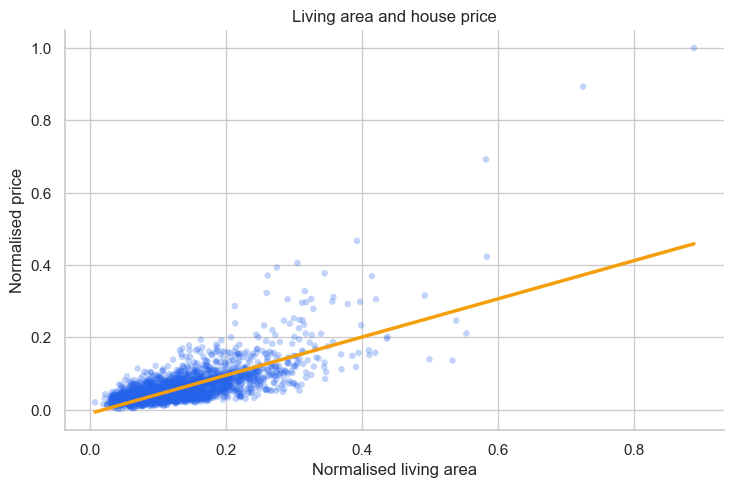

In [4]:
plot_sample = housing.sample(2500, random_state=42)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.regplot(data=plot_sample, x="sqft_living", y="price", ci=None,
            scatter_kws={"s": 22, "alpha": 0.28, "color": "#2563EB", "edgecolor": "none"},
            line_kws={"color": "#F59E0B", "linewidth": 2.5}, ax=ax)
ax.set(title="Living area and house price", xlabel="Normalised living area", ylabel="Normalised price")
sns.despine()
plt.show()

A scatter plot is suitable for two numeric variables. The sample reduces overplotting while the fixed random state keeps the result reproducible.


## 5. Ranking: bar chart

**Question:** How does average price change across building grades?


In [5]:
housing["grade_level"] = (housing["grade"] * 12 + 1).round().astype(int)
grade_summary = (housing.groupby("grade_level")["price"]
                 .agg(average_price="mean", homes="size")
                 .query("homes >= 25")
                 .reset_index())
grade_summary

,grade_level,average_price,homes
0,4,0.018279,29
1,5,0.022757,242
2,6,0.029760,2038
3,7,0.042963,8981
4,8,0.061358,6068
5,9,0.091608,2615
6,10,0.130724,1134
7,11,0.186471,399
8,12,0.277537,90


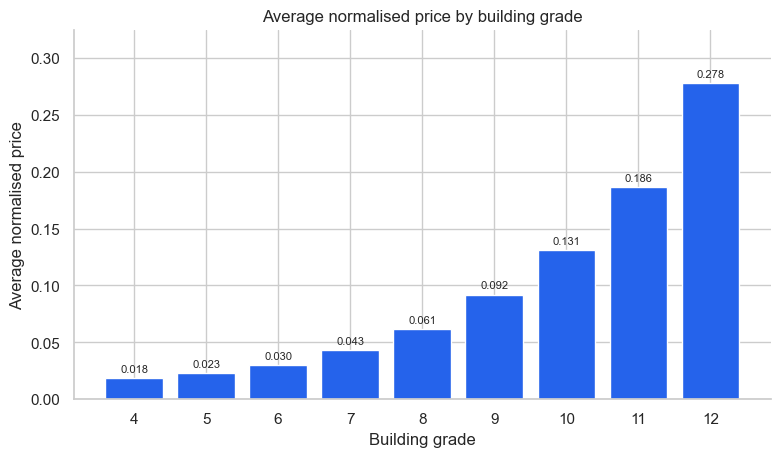

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(grade_summary["grade_level"].astype(str), grade_summary["average_price"], color="#2563EB")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set(title="Average normalised price by building grade", xlabel="Building grade", ylabel="Average normalised price")
ax.set_ylim(0, grade_summary["average_price"].max() * 1.17)
sns.despine()
plt.show()

A bar chart makes the ordered grade comparison easy to scan. Grades with fewer than 25 homes are excluded because their averages are unstable.


## 6. Group distributions: box plot

**Question:** Do waterfront homes have a different price distribution?


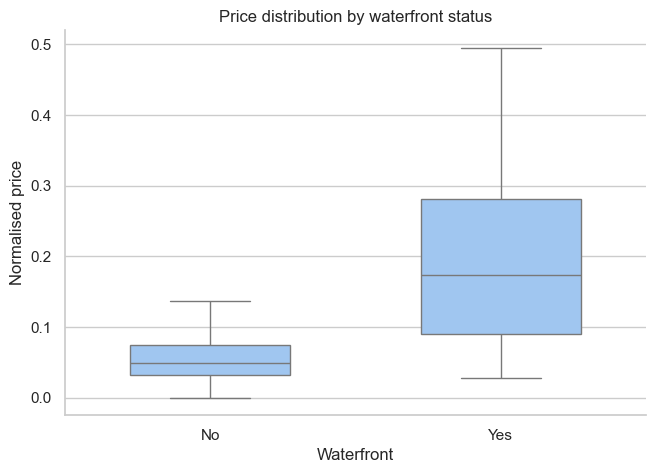

In [7]:
housing["Waterfront"] = housing["waterfront"].map({0.0: "No", 1.0: "Yes"})
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.boxplot(data=housing, x="Waterfront", y="price", order=["No", "Yes"],
            color="#93C5FD", showfliers=False, width=0.55, ax=ax)
ax.set(title="Price distribution by waterfront status", xlabel="Waterfront", ylabel="Normalised price")
sns.despine()
plt.show()

A box plot compares the median and spread of two groups. Individual outlier points are hidden here so the boxes remain readable; the rows are not removed from the analysis.


## 7. Multiple relationships: correlation heatmap

**Question:** Which numeric features have the strongest linear relationship with price?


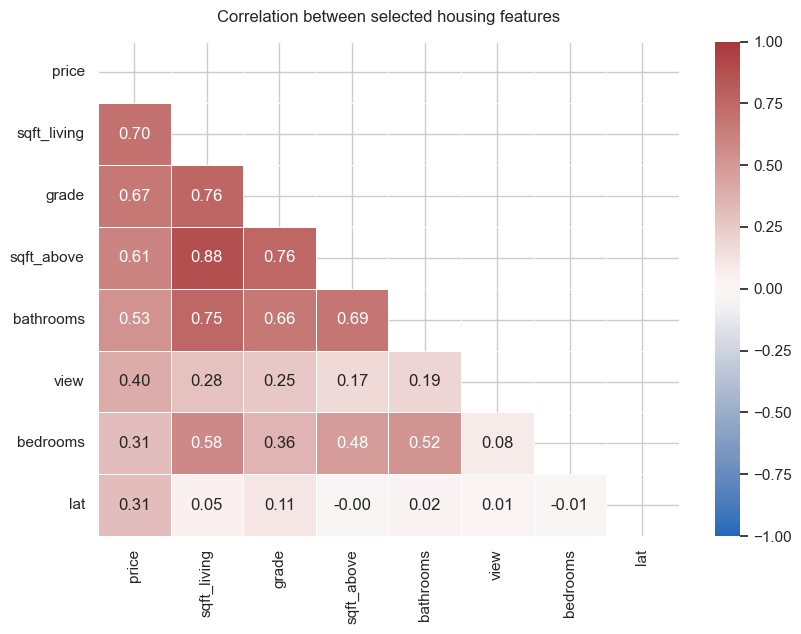

In [8]:
correlation_columns = ["price", "sqft_living", "grade", "sqft_above",
                       "bathrooms", "view", "bedrooms", "lat"]
correlation = housing[correlation_columns].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(correlation, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Correlation between selected housing features", pad=14)
plt.tight_layout()
plt.show()

A heatmap is useful for scanning several relationships at once. Correlation describes linear association, not causation.


## my lessons learned

- Prices are strongly right-skewed, with a small number of expensive homes.
- Living area and building grade have clear positive relationships with price.
- Waterfront homes have a higher price distribution, although the groups are very different in size.
- The best chart depends on whether the question concerns distribution, comparison or relationship.
